# CISC3024 AI Assignment #1 — Ablation Cells
## Four single-variable experiments on top of your finished MobileNetV4 run

Each ablation changes **exactly one** variable and writes to its **own folder**
under `MyDrive/cisc3024_ai1/runs/`, so nothing overwrites your main run.

| # | Ablation | Variable changed | `out_dir` |
|---|----------|------------------|-----------|
| 1 | Baseline comparison | `model_name` -> `resnet18` | `runs/abl_01_resnet18` |
| 2 | Model scale | `model_name` -> `mobilenetv4_conv_medium...` | `runs/abl_02_mnv4_medium` |
| 3 | Input resolution | `img_size` -> `128` | `runs/abl_03_img128` |
| 4 | Fine-tuning strategy | `freeze_backbone` -> `True` | `runs/abl_04_freeze_backbone` |

### How to run
1. Run **Cell 2 (shared setup)** once. It defines `run_experiment(...)`.
2. Run any of the four ablation cells — in any order, or just the one you need.
3. Run the final comparison cell to get the results table for your report.

### Two things worth knowing before you start

**a) `epochs` is deliberately identical (12) across all runs.** That is what makes
them comparable — changing the schedule as well as the variable would confound the
result. It does mean roughly 2 hours of GPU time for all four; run them one at a
time and rely on resume if Colab disconnects.

**b) The parameter counts timm reports differ from the paper.** The MobileNetV4
paper quotes 3.77 M for `conv_small` and 9.72 M for `conv_medium`; `timm` 1.0.29
reports **2.51 M** and **8.45 M**. The paper's figures are measured before folding
normalisation parameters into the convolutions; timm's are the actual trained
tensors. Report whichever you measure yourself, and say which convention you used —
this is exactly the kind of detail that earns marks.


## Cell 2 — Shared setup (run this once)

Defines paths, the baseline config, and a single `run_experiment(tag, **overrides)`
function that does the whole pipeline: data -> model -> train (with resume) ->
evaluate -> save artefacts into its own folder.


In [1]:
# =============================================================================
# Shared setup for the four ablation runs
# =============================================================================
import os, sys, gc, json, time, random, shutil, contextlib
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

import timm

# --- Google Drive -----------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive/cisc3024_ai1"
else:
    DRIVE_ROOT = os.path.abspath("./cisc3024_ai1")

DATA_DIR  = os.path.join(DRIVE_ROOT, "data")   # shared CIFAR-10 cache
RUNS_ROOT = os.path.join(DRIVE_ROOT, "runs")   # one sub-folder per experiment
Path(RUNS_ROOT).mkdir(parents=True, exist_ok=True)

MAIN_RUN_TAG = "mnv4_cifar10"                  # the run you already finished

print("DRIVE_ROOT :", DRIVE_ROOT)
print("DATA_DIR   :", DATA_DIR)
print("RUNS_ROOT  :", RUNS_ROOT)

# --- baseline config: the settings of your finished main run ----------------
BASE = {
    "model_name":      "mobilenetv4_conv_small.e2400_r224_in1k",
    "img_size":        224,
    "batch_size":      128,
    "epochs":          12,
    "lr":              3e-4,
    "weight_decay":    0.05,
    "label_smoothing": 0.1,
    "warmup_epochs":   1,
    "num_workers":     2,
    "val_frac":        0.10,
    "num_classes":     10,
    "seed":            42,
    "amp":             True,
    "patience":        4,
    "freeze_backbone": False,
    "freeze_mode":     "head",   # "head" = timm forward_head | "classifier" = final linear only
    "resume":          True,
}

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# --- dataset wrapper --------------------------------------------------------
class CifarWrap(Dataset):
    """Applies a transform to a (subset of a) CIFAR-10 dataset."""
    def __init__(self, base, tf, indices=None):
        self.base = base
        self.tf = tf
        self.indices = list(range(len(base))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, y = self.base[self.indices[i]]
        return self.tf(img), y


# --- model ------------------------------------------------------------------
def build_model(model_name, num_classes=10):
    """Load a pretrained timm model.

    Two failure modes are handled explicitly:
      1. the exact weight tag is unknown to this timm version -> retry the short name
      2. the HuggingFace cache holds a truncated file (common after an interrupted
         Colab download) -> say so, because retrying will never fix it
    """
    try:
        return timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    except Exception as e:
        msg = str(e).lower()
        if "header too small" in msg or "safetensor" in msg or "unexpected end" in msg:
            print("  !! The cached pretrained weights are corrupt (truncated download).")
            print("     Fix it by clearing the cache, then re-run this cell:")
            print("       !rm -rf ~/.cache/huggingface/hub")
            raise

        short = model_name.split(".")[0]
        print(f"  weight tag '{model_name}' failed ({type(e).__name__}); "
              f"retrying as '{short}'")
        return timm.create_model(short, pretrained=True, num_classes=num_classes)


def head_module_names(model):
    """timm convention: every top-level module AFTER global_pool is the head.

    Verified against timm 1.0.29:
      mobilenetv4_* -> ('conv_head', 'norm_head', 'act2', 'flatten', 'classifier')
      resnet18     -> ('fc',)
    """
    children = [n for n, _ in model.named_children()]
    if "global_pool" in children:
        return tuple(children[children.index("global_pool") + 1:])
    return ("head", "classifier", "fc", "conv_head", "last_linear")


def freeze_backbone(model, mode="head"):
    """Freeze the feature extractor, leaving only the head trainable.

    Returns (head_module_names, frozen_bn_modules).
    """
    if mode == "classifier":
        names = (model.default_cfg.get("classifier") or "classifier",)
    else:
        names = head_module_names(model)

    prefixes = tuple(n + "." for n in names)
    for p in model.parameters():
        p.requires_grad = False
    for name, p in model.named_parameters():
        if name.startswith(prefixes):
            p.requires_grad = True

    # BatchNorm layers whose parameters are now frozen MUST stay in eval() mode.
    # Otherwise their running mean/var keep drifting during training and the
    # "frozen" backbone is not actually frozen.
    frozen_bn = [m for m in model.modules()
                 if isinstance(m, nn.modules.batchnorm._BatchNorm)
                 and not any(p.requires_grad for p in m.parameters())]
    return names, frozen_bn


# --- checkpointing ----------------------------------------------------------
def atomic_save(obj, path):
    """Temp file + atomic rename, so a disconnect mid-write cannot corrupt it."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


def safe_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                    best_acc, bad_epochs, history):
    atomic_save({
        "epoch": epoch, "model": model.state_dict(),
        "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(), "best_acc": best_acc,
        "bad_epochs": bad_epochs, "history": history,
        "rng": {"torch": torch.get_rng_state(),
                "numpy": np.random.get_state(),
                "python": random.getstate()},
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    ckpt = safe_load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    if ckpt.get("scaler") is not None:
        try:
            scaler.load_state_dict(ckpt["scaler"])
        except Exception as e:
            print("  (scaler state not restored:", e, ")")
    rng = ckpt.get("rng")
    if rng:
        try:
            # torch.set_rng_state() only accepts a *contiguous CPU* ByteTensor
            # (ATen/core/Generator.h -> check_rng_state). safe_load() above uses
            # map_location=device, which moves EVERY tensor in the checkpoint onto
            # the GPU -- the RNG state included. It therefore has to be pinned back
            # to CPU here, or PyTorch raises "RNG state must be a torch.ByteTensor"
            # even though the dtype really is uint8. The old code also aborted on
            # the first line, so the numpy/python RNG states were never restored
            # either; each is now guarded independently.
            st = rng["torch"] if isinstance(rng, dict) else rng
            if not isinstance(st, torch.Tensor):
                st = torch.as_tensor(st)
            torch.set_rng_state(
                st.detach().to(device="cpu", dtype=torch.uint8).contiguous())
            if isinstance(rng, dict):
                if rng.get("numpy") is not None:
                    np.random.set_state(rng["numpy"])
                if rng.get("python") is not None:
                    random.setstate(rng["python"])
        except Exception as e:
            print("  (RNG state not restored:", e, ")")
    return (ckpt["epoch"] + 1, ckpt.get("best_acc", 0.0),
            ckpt.get("bad_epochs", 0), ckpt.get("history"))


# --- train / evaluate -------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, scheduler,
                    device, frozen_bn=None, autocast_ctx=None):
    ctx = autocast_ctx if autocast_ctx is not None else contextlib.nullcontext

    model.train()
    if frozen_bn:                       # keep frozen BN in eval mode
        for m in frozen_bn:
            m.eval()

    tot = correct = 0
    loss_sum = 0.0
    skipped = 0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with ctx():
            logits = model(images)
            loss = criterion(logits, targets)

        # optimizer.step() first, scheduler.step() last, and only if the step ran
        scale_before = scaler.get_scale()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scaler.get_scale() >= scale_before:
            scheduler.step()
        else:
            skipped += 1

        loss_sum += loss.item() * images.size(0)
        correct  += (logits.argmax(1) == targets).sum().item()
        tot      += images.size(0)

    if skipped:
        print(f"    (note: {skipped} step(s) skipped by GradScaler)")
    return loss_sum / tot, correct / tot


@torch.no_grad()
def evaluate(model, loader, criterion, device, autocast_ctx=None):
    ctx = autocast_ctx if autocast_ctx is not None else contextlib.nullcontext
    model.eval()
    tot = correct = 0
    loss_sum = 0.0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with ctx():
            logits = model(images)
            loss = criterion(logits, targets)
        loss_sum += loss.item() * images.size(0)
        correct  += (logits.argmax(1) == targets).sum().item()
        tot      += images.size(0)
    return loss_sum / tot, correct / tot


# =============================================================================
# The one function every ablation cell calls
# =============================================================================
def run_experiment(tag, **overrides):
    """Train + evaluate one experiment. Writes everything into RUNS_ROOT/<tag>."""
    cfg = {**BASE, **overrides}
    out_dir = os.path.join(RUNS_ROOT, tag)
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    ckpt_last = os.path.join(out_dir, "last.pt")
    ckpt_best = os.path.join(out_dir, "best.pt")

    changed = {k: v for k, v in overrides.items() if BASE.get(k) != v}

    print("=" * 78)
    print(f"EXPERIMENT : {tag}")
    print("=" * 78)
    print("variable   :", changed if changed else "(none - identical to baseline)")
    print("out_dir    :", out_dir)

    set_seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # If this experiment has already run, keep the timing it recorded: a
    # fully-resumed run executes no epochs, so it would otherwise overwrite a
    # good sec/epoch value with None.
    prev = {}
    prev_path = os.path.join(out_dir, "results.json")
    if os.path.isfile(prev_path):
        try:
            with open(prev_path) as f:
                prev = json.load(f)
        except Exception:
            prev = {}

    # ---------------- data (shared Drive cache) ------------------------------
    S = cfg["img_size"]
    RESIZE = int(round(S * 256 / 224))
    train_tf = transforms.Compose([
        transforms.Resize(RESIZE),
        transforms.RandomCrop(S),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
        transforms.RandomErasing(p=0.25, value="random"),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize(RESIZE),
        transforms.CenterCrop(S),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])

    base_train = datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=None)
    base_test  = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=None)

    # fixed seed -> identical split across every run, so the comparison is fair
    g = torch.Generator().manual_seed(cfg["seed"])
    perm = torch.randperm(len(base_train), generator=g).tolist()
    n_val = int(len(base_train) * cfg["val_frac"])
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    train_loader = DataLoader(CifarWrap(base_train, train_tf, train_idx),
                              batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=cfg["num_workers"], pin_memory=True,
                              drop_last=True)
    val_loader   = DataLoader(CifarWrap(base_train, eval_tf, val_idx),
                              batch_size=256, shuffle=False,
                              num_workers=cfg["num_workers"], pin_memory=True)
    test_loader  = DataLoader(CifarWrap(base_test, eval_tf),
                              batch_size=256, shuffle=False,
                              num_workers=cfg["num_workers"], pin_memory=True)
    CLASSES = base_test.classes

    # ---------------- model --------------------------------------------------
    model = build_model(cfg["model_name"], cfg["num_classes"]).to(device)
    total_params = sum(p.numel() for p in model.parameters())

    frozen_bn = None
    head_names = None
    if cfg["freeze_backbone"]:
        head_names, frozen_bn = freeze_backbone(model, cfg["freeze_mode"])
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"model      : {cfg['model_name']}")
    print(f"img_size   : {S}  (resize short side to {RESIZE}, then crop)")
    print(f"params     : {total_params/1e6:.3f} M total | "
          f"{trainable_params/1e6:.3f} M trainable "
          f"({trainable_params/total_params*100:.1f}%)")
    if cfg["freeze_backbone"]:
        print(f"freeze mode: '{cfg['freeze_mode']}' -> head modules {head_names}")
        print(f"             {len(frozen_bn)} BatchNorm layer(s) pinned to eval()")

    # ---------------- optimiser ---------------------------------------------
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg["label_smoothing"])

    decay, no_decay = [], []
    for _, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim <= 1 else decay).append(p)
    optimizer = torch.optim.AdamW(
        [{"params": decay,    "weight_decay": cfg["weight_decay"]},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=cfg["lr"])

    steps_per_epoch = len(train_loader)
    total_steps  = cfg["epochs"] * steps_per_epoch
    warmup_steps = cfg["warmup_epochs"] * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + np.cos(np.pi * prog))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    USE_AMP = cfg["amp"] and device.type == "cuda"
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
        def autocast_ctx():
            return torch.amp.autocast("cuda", dtype=torch.float16, enabled=USE_AMP)
    except (TypeError, AttributeError):
        scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
        def autocast_ctx():
            return torch.cuda.amp.autocast(enabled=USE_AMP)

    # ---------------- train --------------------------------------------------
    history    = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc", "lr")}
    epoch_times = []
    best_acc   = 0.0
    bad_epochs = 0
    start_epoch = 1

    if cfg["resume"] and os.path.isfile(ckpt_last):
        start_epoch, best_acc, bad_epochs, hist = load_checkpoint(
            ckpt_last, model, optimizer, scheduler, scaler, device)
        if hist:
            history = hist
        print(f"resumed    : next epoch {start_epoch}, best val {best_acc:.4f}")

    for epoch in range(start_epoch, cfg["epochs"] + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                          scaler, scheduler, device, frozen_bn,
                                          autocast_ctx=autocast_ctx)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device,
                                   autocast_ctx=autocast_ctx)
        dt = time.time() - t0
        epoch_times.append(dt)
        lr = optimizer.param_groups[0]["lr"]

        for k, v in zip(("train_loss", "train_acc", "val_loss", "val_acc", "lr"),
                        (tr_loss, tr_acc, va_loss, va_acc, lr)):
            history[k].append(v)

        flag = ""
        if va_acc > best_acc:
            best_acc, bad_epochs, flag = va_acc, 0, "   <- best"
            save_checkpoint(ckpt_best, epoch, model, optimizer, scheduler, scaler,
                            best_acc, bad_epochs, history)
        else:
            bad_epochs += 1
        save_checkpoint(ckpt_last, epoch, model, optimizer, scheduler, scaler,
                        best_acc, bad_epochs, history)

        print(f"  epoch {epoch:2d}/{cfg['epochs']} | "
              f"train {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val {va_loss:.4f} acc {va_acc:.4f} | "
              f"lr {lr:.2e} | {dt:5.1f}s{flag}")

        if bad_epochs >= cfg["patience"]:
            print(f"  early stopping at epoch {epoch}")
            break

    # ---------------- evaluate on the held-out test set ----------------------
    ckpt = safe_load(ckpt_best, map_location=device)
    model.load_state_dict(ckpt["model"])
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"  TEST  loss {test_loss:.4f}   accuracy {test_acc:.4f}")

    # ---------------- artefacts ---------------------------------------------
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title(f"{tag} - loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
    ax[1].set_title(f"{tag} - accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "curves.png"), dpi=140)
    plt.show()

    from sklearn.metrics import confusion_matrix, classification_report
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for images, targets in test_loader:
            with autocast_ctx():
                logits = model(images.to(device))
            ps.append(logits.argmax(1).cpu()); ys.append(targets)
    ys = torch.cat(ys).numpy(); ps = torch.cat(ps).numpy()

    report = classification_report(ys, ps, target_names=CLASSES, digits=4)
    print(report)

    cm = confusion_matrix(ys, ps)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{tag} confusion matrix (test acc {test_acc:.3f})")
    for i in range(10):
        for j in range(10):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im); plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "confusion_matrix.png"), dpi=140)
    plt.show()

    summary = {
        "tag": tag,
        "model_name": cfg["model_name"],
        "img_size": cfg["img_size"],
        "batch_size": cfg["batch_size"],
        "epochs_planned": cfg["epochs"],
        "epochs_run": len(history["train_loss"]),
        "freeze_backbone": cfg["freeze_backbone"],
        "freeze_mode": cfg["freeze_mode"] if cfg["freeze_backbone"] else None,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "best_val_acc": float(best_acc),
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
        "sec_per_epoch_mean": (float(np.mean(epoch_times)) if epoch_times
                               else prev.get("sec_per_epoch_mean")),
        "history": history,
        "cfg": cfg,
        "out_dir": out_dir,
    }
    with open(os.path.join(out_dir, "results.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # ---------------- free memory before the next run ------------------------
    del model, optimizer, scheduler, scaler
    del train_loader, val_loader, test_loader, train_tf, eval_tf
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"  artefacts -> {out_dir}")
    print(f"  SUMMARY   -> test acc {test_acc:.4f} | best val {best_acc:.4f} | "
          f"trainable {trainable_params/1e6:.3f} M")
    print()
    return summary

Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive/cisc3024_ai1
DATA_DIR   : /content/drive/MyDrive/cisc3024_ai1/data
RUNS_ROOT  : /content/drive/MyDrive/cisc3024_ai1/runs


## Ablation 1 — Baseline comparison (`resnet18`)

**Variable changed:** `model_name` only.

ResNet-18 is the standard classical baseline for this kind of study: 11.18 M
parameters, no depthwise convolutions, no NAS. If MobileNetV4 beats it at a
quarter of the size, that is the headline result of your ablation section.

Expected: ResNet-18 should be **slower per epoch** (dense 3×3 convolutions) but
competitive on accuracy, because CIFAR-10 is an easy dataset and 11 M parameters
is plenty.


EXPERIMENT : abl_01_resnet18
variable   : {'model_name': 'resnet18'}
out_dir    : /content/drive/MyDrive/cisc3024_ai1/runs/abl_01_resnet18


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

model      : resnet18
img_size   : 224  (resize short side to 256, then crop)
params     : 11.182 M total | 11.182 M trainable (100.0%)
  epoch  1/12 | train 1.6503 acc 0.5273 | val 0.8173 acc 0.8766 | lr 3.00e-04 | 153.6s   <- best
  epoch  2/12 | train 0.8464 acc 0.8589 | val 0.6920 acc 0.9280 | lr 2.94e-04 | 163.5s   <- best
  epoch  3/12 | train 0.7619 acc 0.8941 | val 0.6621 acc 0.9398 | lr 2.76e-04 | 167.2s   <- best
  epoch  4/12 | train 0.7197 acc 0.9125 | val 0.6412 acc 0.9458 | lr 2.48e-04 | 166.2s   <- best
  epoch  5/12 | train 0.6975 acc 0.9214 | val 0.6401 acc 0.9464 | lr 2.12e-04 | 168.0s   <- best
  epoch  6/12 | train 0.6761 acc 0.9305 | val 0.6205 acc 0.9540 | lr 1.71e-04 | 167.5s   <- best
  epoch  7/12 | train 0.6623 acc 0.9376 | val 0.6144 acc 0.9576 | lr 1.29e-04 | 165.7s   <- best
  epoch  8/12 | train 0.6496 acc 0.9432 | val 0.6113 acc 0.9578 | lr 8.77e-05 | 167.8s   <- best
  epoch  9/12 | train 0.6400 acc 0.9476 | val 0.6088 acc 0.9584 | lr 5.18e-05 | 169.1s  

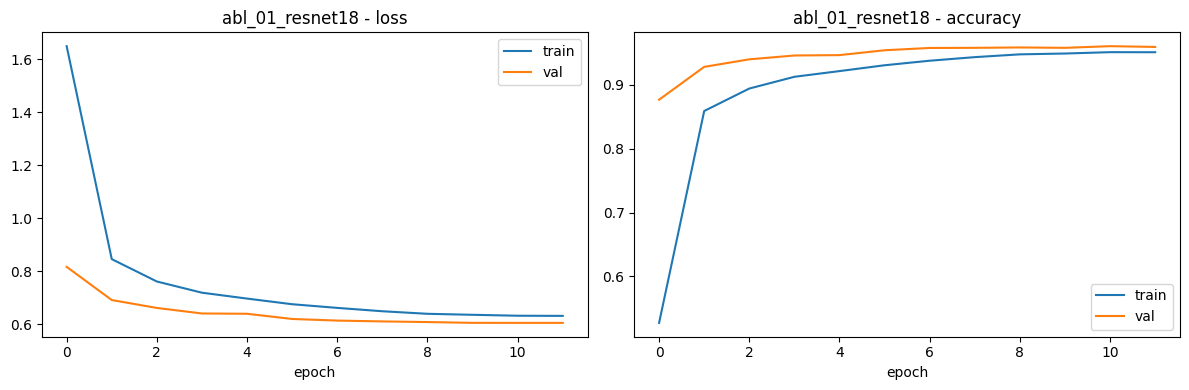

              precision    recall  f1-score   support

    airplane     0.9718    0.9650    0.9684      1000
  automobile     0.9712    0.9780    0.9746      1000
        bird     0.9615    0.9500    0.9557      1000
         cat     0.9224    0.9030    0.9126      1000
        deer     0.9551    0.9570    0.9560      1000
         dog     0.9242    0.9260    0.9251      1000
        frog     0.9732    0.9790    0.9761      1000
       horse     0.9655    0.9790    0.9722      1000
        ship     0.9723    0.9820    0.9771      1000
       truck     0.9700    0.9690    0.9695      1000

    accuracy                         0.9588     10000
   macro avg     0.9587    0.9588    0.9587     10000
weighted avg     0.9587    0.9588    0.9587     10000



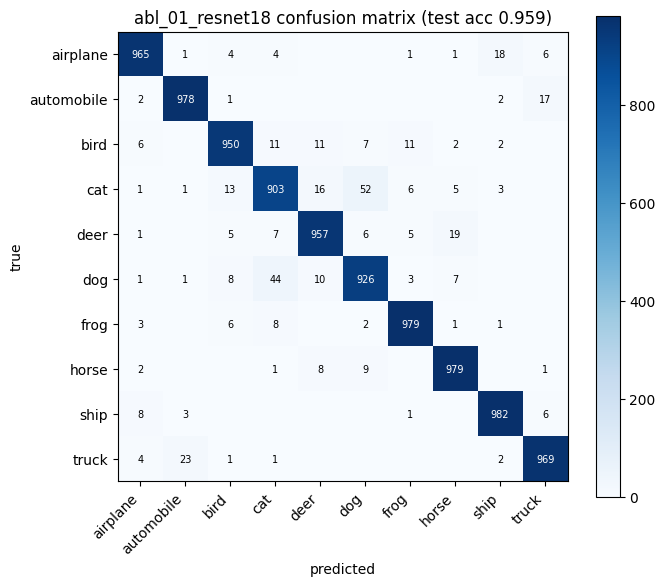

  artefacts -> /content/drive/MyDrive/cisc3024_ai1/runs/abl_01_resnet18
  SUMMARY   -> test acc 0.9588 | best val 0.9604 | trainable 11.182 M



In [2]:
summary_resnet18 = run_experiment("abl_01_resnet18", model_name="resnet18")

## Ablation 2 — Model scale (`mobilenetv4_conv_medium`)

**Variable changed:** `model_name` only.

Same architecture family, larger variant: 8.45 M parameters vs 2.51 M for
`conv_small`. This isolates the effect of **capacity** from the effect of the
architecture, which is the cleanest single comparison in the whole table.

Expected: higher accuracy, roughly 3× the per-epoch time.


EXPERIMENT : abl_02_mnv4_medium
variable   : {'model_name': 'mobilenetv4_conv_medium.e500_r224_in1k'}
out_dir    : /content/drive/MyDrive/cisc3024_ai1/runs/abl_02_mnv4_medium


model.safetensors: reconstructing file:   0%|          |  0.00B / 39.2MB            

model.safetensors: downloading bytes:           |  0.00B            

model      : mobilenetv4_conv_medium.e500_r224_in1k
img_size   : 224  (resize short side to 256, then crop)
params     : 8.447 M total | 8.447 M trainable (100.0%)
    (note: 9 step(s) skipped by GradScaler)
  epoch  1/12 | train 2.1741 acc 0.6478 | val 0.7947 acc 0.8850 | lr 2.93e-04 | 198.8s   <- best
  epoch  2/12 | train 0.8453 acc 0.8587 | val 1.2053 acc 0.9082 | lr 2.94e-04 | 175.0s   <- best
  epoch  3/12 | train 0.7615 acc 0.8955 | val 0.9716 acc 0.9100 | lr 2.77e-04 | 177.9s   <- best
  epoch  4/12 | train 0.7078 acc 0.9145 | val 0.7552 acc 0.9360 | lr 2.49e-04 | 179.7s   <- best
  epoch  5/12 | train 0.6667 acc 0.9328 | val 0.7255 acc 0.9420 | lr 2.13e-04 | 179.4s   <- best
  epoch  6/12 | train 0.6313 acc 0.9465 | val 0.6851 acc 0.9528 | lr 1.72e-04 | 180.6s   <- best
  epoch  7/12 | train 0.6020 acc 0.9590 | val 0.7609 acc 0.9536 | lr 1.30e-04 | 181.9s   <- best
  epoch  8/12 | train 0.5790 acc 0.9689 | val 0.7229 acc 0.9642 | lr 8.87e-05 | 181.1s   <- best
  epoch  9/12 | 

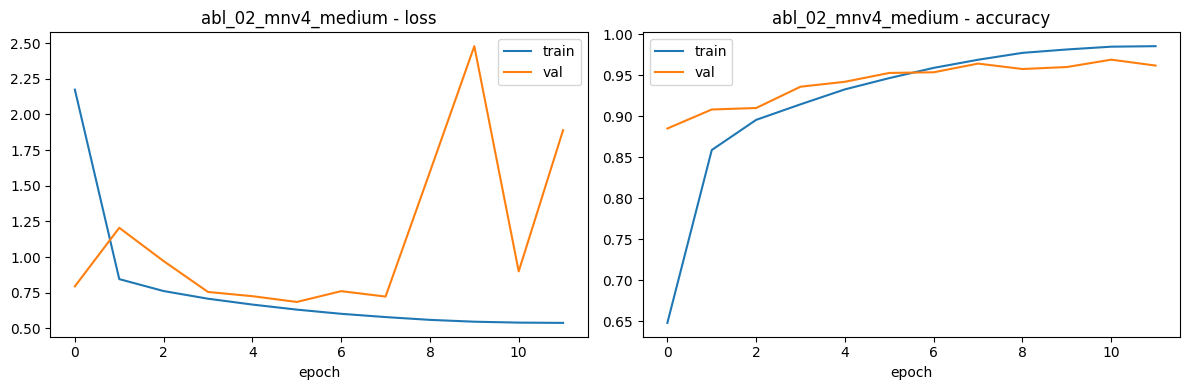

              precision    recall  f1-score   support

    airplane     0.9742    0.9800    0.9771      1000
  automobile     0.9382    0.9860    0.9615      1000
        bird     0.9691    0.9710    0.9700      1000
         cat     0.9496    0.9240    0.9366      1000
        deer     0.9722    0.9810    0.9766      1000
         dog     0.9337    0.9570    0.9452      1000
        frog     0.9879    0.9800    0.9839      1000
       horse     0.9916    0.9420    0.9662      1000
        ship     0.9889    0.9780    0.9834      1000
       truck     0.9741    0.9770    0.9755      1000

    accuracy                         0.9676     10000
   macro avg     0.9679    0.9676    0.9676     10000
weighted avg     0.9679    0.9676    0.9676     10000



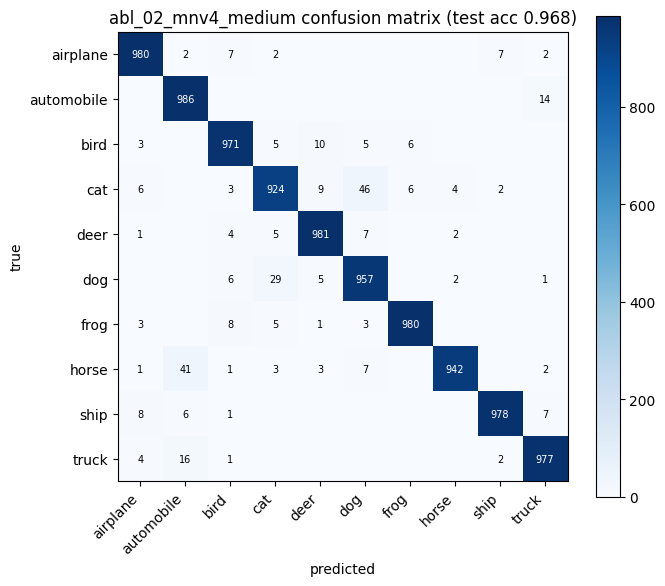

  artefacts -> /content/drive/MyDrive/cisc3024_ai1/runs/abl_02_mnv4_medium
  SUMMARY   -> test acc 0.9675 | best val 0.9690 | trainable 8.447 M



In [3]:
summary_medium = run_experiment(
    "abl_02_mnv4_medium",
    model_name="mobilenetv4_conv_medium.e500_r224_in1k",
)

## Ablation 3 — Input resolution (`img_size = 128`)

**Variable changed:** `img_size` only (224 -> 128). `batch_size` is left at 128
so that resolution is the only difference.

Why this matters here: CIFAR-10 is 32×32 natively, so both 128 and 224 are
upsamples. This ablation answers whether the extra 1.75× pixels actually buy
accuracy, or whether the pretrained weights already saturate at 128 — a very
practical finding if you ever need to run this faster.

Expected: ~4× faster per epoch, a small accuracy drop. If the drop is under
1 point, 128 is the better default for iteration.


EXPERIMENT : abl_03_img128
variable   : {'img_size': 128}
out_dir    : /content/drive/MyDrive/cisc3024_ai1/runs/abl_03_img128


model.safetensors: reconstructing file:   0%|          |  0.00B / 15.2MB            

model.safetensors: downloading bytes:           |  0.00B            

model      : mobilenetv4_conv_small.e2400_r224_in1k
img_size   : 128  (resize short side to 146, then crop)
params     : 2.506 M total | 2.506 M trainable (100.0%)
    (note: 8 step(s) skipped by GradScaler)
  epoch  1/12 | train 2.1448 acc 0.5221 | val 1.0640 acc 0.7734 | lr 2.94e-04 |  87.8s   <- best
  epoch  2/12 | train 0.9964 acc 0.7957 | val 0.8095 acc 0.8682 | lr 2.94e-04 |  81.3s   <- best
  epoch  3/12 | train 0.8602 acc 0.8487 | val 0.7595 acc 0.8872 | lr 2.77e-04 |  81.6s   <- best
  epoch  4/12 | train 0.8041 acc 0.8708 | val 0.7080 acc 0.9128 | lr 2.49e-04 |  82.7s   <- best
  epoch  5/12 | train 0.7603 acc 0.8904 | val 0.6871 acc 0.9234 | lr 2.13e-04 |  81.7s   <- best
  epoch  6/12 | train 0.7249 acc 0.9047 | val 0.6640 acc 0.9308 | lr 1.72e-04 |  81.1s   <- best
  epoch  7/12 | train 0.6953 acc 0.9180 | val 0.6377 acc 0.9410 | lr 1.30e-04 |  83.2s   <- best
  epoch  8/12 | train 0.6673 acc 0.9308 | val 0.6289 acc 0.9456 | lr 8.86e-05 |  82.6s   <- best
  epoch  9/12 | 

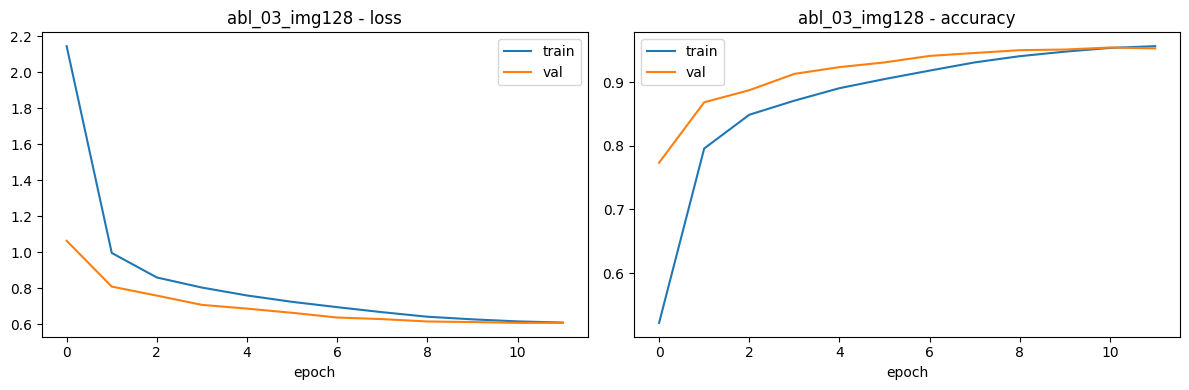

              precision    recall  f1-score   support

    airplane     0.9630    0.9630    0.9630      1000
  automobile     0.9664    0.9790    0.9727      1000
        bird     0.9631    0.9390    0.9509      1000
         cat     0.9035    0.8710    0.8870      1000
        deer     0.9313    0.9620    0.9464      1000
         dog     0.8961    0.9140    0.9050      1000
        frog     0.9700    0.9690    0.9695      1000
       horse     0.9671    0.9690    0.9680      1000
        ship     0.9683    0.9770    0.9726      1000
       truck     0.9756    0.9610    0.9683      1000

    accuracy                         0.9504     10000
   macro avg     0.9504    0.9504    0.9503     10000
weighted avg     0.9504    0.9504    0.9503     10000



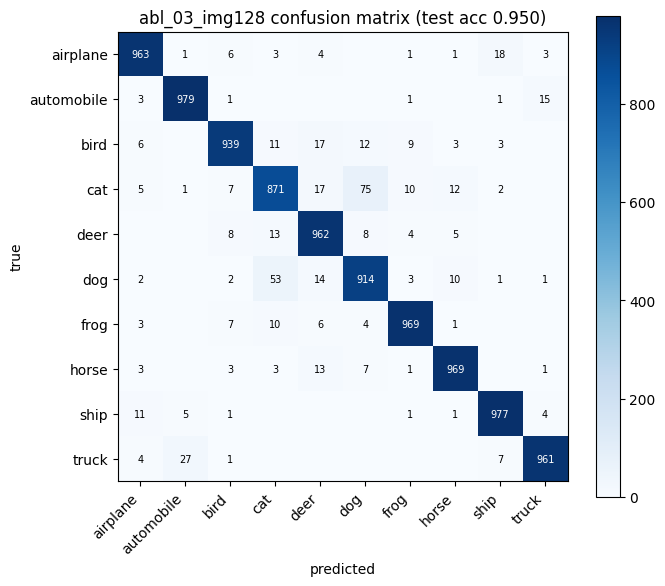

  artefacts -> /content/drive/MyDrive/cisc3024_ai1/runs/abl_03_img128
  SUMMARY   -> test acc 0.9504 | best val 0.9542 | trainable 2.506 M



In [4]:
summary_img128 = run_experiment("abl_03_img128", img_size=128)

## Ablation 4 — Fine-tuning strategy (freeze the backbone)

**Variable changed:** `freeze_backbone` only (False -> True). Everything else,
including `model_name`, stays at the `conv_small` baseline.

`freeze_mode="head"` uses timm's own `forward_head` boundary — verified against
timm 1.0.29, the head of `mobilenetv4_conv_small` is
`('conv_head', 'norm_head', 'act2', 'flatten', 'classifier')`.

> **Read this before interpreting the result.** For MobileNetV4 the head includes
> `conv_head`, a 1×1 convolution that expands to 1280 channels — 1.23 M
> parameters. So freezing the backbone of `conv_small` still leaves
> **1.244 M of 2.506 M parameters trainable (49.7%)**. This is *not* a tiny
> linear probe; it is training half the network.
>
> If you want the strict "train only the final linear layer" version instead,
> switch the mode:
> ```python
> summary_frozen = run_experiment("abl_04b_freeze_classifier",
>                                 freeze_backbone=True, freeze_mode="classifier")
> ```
> That leaves just 12 810 parameters trainable (0.5%). Running both variants
> makes for a genuinely interesting comparison — "how much of the head has to
> stay trainable?" — and it is a cheap extra run.

BatchNorm note: frozen BN layers are explicitly pinned back to `eval()` after
each `model.train()` call, otherwise their running statistics would keep drifting
and the backbone would not really be frozen.


EXPERIMENT : abl_04_freeze_backbone
variable   : {'freeze_backbone': True}
out_dir    : /content/drive/MyDrive/cisc3024_ai1/runs/abl_04_freeze_backbone
model      : mobilenetv4_conv_small.e2400_r224_in1k
img_size   : 224  (resize short side to 256, then crop)
params     : 2.506 M total | 1.244 M trainable (49.7%)
freeze mode: 'head' -> head modules ('conv_head', 'norm_head', 'act2', 'flatten', 'classifier')
             45 BatchNorm layer(s) pinned to eval()
  epoch  1/12 | train 2.2287 acc 0.5851 | val 1.3789 acc 0.7934 | lr 3.00e-04 | 158.4s   <- best
  epoch  2/12 | train 1.3257 acc 0.7494 | val 1.0711 acc 0.8414 | lr 2.94e-04 | 150.3s   <- best
  epoch  3/12 | train 1.1165 acc 0.7916 | val 0.9509 acc 0.8680 | lr 2.76e-04 | 152.7s   <- best
  epoch  4/12 | train 1.0148 acc 0.8166 | val 0.9021 acc 0.8824 | lr 2.48e-04 | 150.6s   <- best
  epoch  5/12 | train 0.9513 acc 0.8363 | val 0.8342 acc 0.8946 | lr 2.12e-04 | 153.3s   <- best
  epoch  6/12 | train 0.9117 acc 0.8487 | val 0.8072

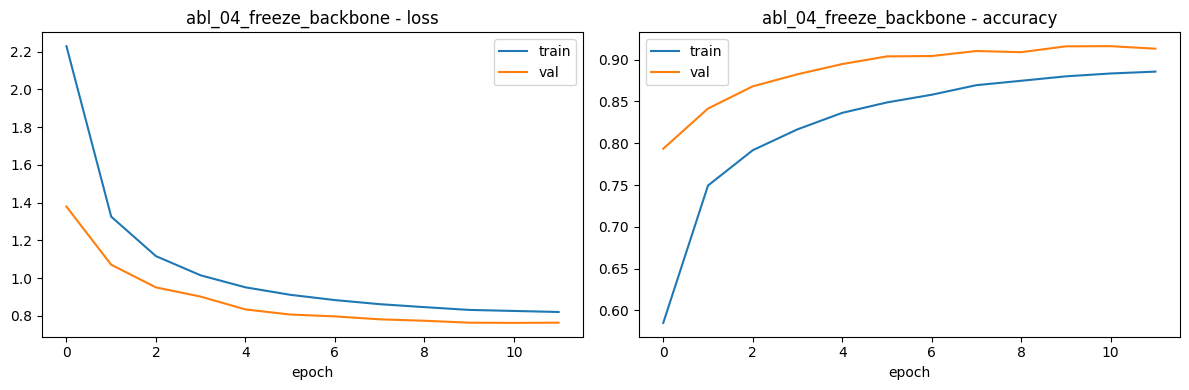

              precision    recall  f1-score   support

    airplane     0.9224    0.9040    0.9131      1000
  automobile     0.9308    0.9550    0.9427      1000
        bird     0.9152    0.8850    0.8998      1000
         cat     0.8724    0.7660    0.8158      1000
        deer     0.8677    0.9050    0.8860      1000
         dog     0.8351    0.8910    0.8621      1000
        frog     0.9192    0.9550    0.9367      1000
       horse     0.9196    0.9260    0.9228      1000
        ship     0.9452    0.9320    0.9386      1000
       truck     0.9255    0.9320    0.9287      1000

    accuracy                         0.9051     10000
   macro avg     0.9053    0.9051    0.9046     10000
weighted avg     0.9053    0.9051    0.9046     10000



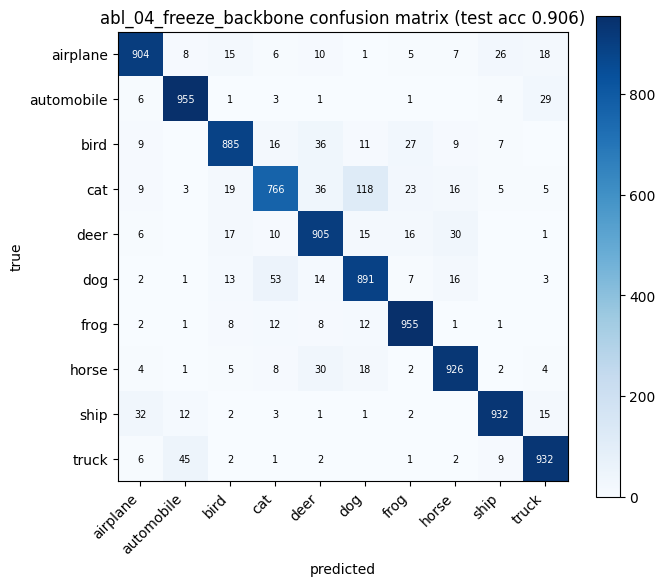

  artefacts -> /content/drive/MyDrive/cisc3024_ai1/runs/abl_04_freeze_backbone
  SUMMARY   -> test acc 0.9056 | best val 0.9160 | trainable 1.244 M



In [5]:
summary_frozen = run_experiment("abl_04_freeze_backbone", freeze_backbone=True)

## Results comparison

Collects every `results.json` under `RUNS_ROOT` — including your original
`mnv4_cifar10` run — into one table for the report.


In [6]:
import pandas as pd

ALL_TAGS = [MAIN_RUN_TAG, "abl_01_resnet18", "abl_02_mnv4_medium",
            "abl_03_img128", "abl_04_freeze_backbone"]

rows = []
for tag in ALL_TAGS:
    p = os.path.join(RUNS_ROOT, tag, "results.json")
    if not os.path.isfile(p):
        print(f"  (skipped {tag}: no results.json yet)")
        continue
    with open(p) as f:
        r = json.load(f)
    cfg = r.get("cfg", {})
    rows.append({
        "run":         tag,
        "model":       r.get("model_name", cfg.get("model_name", "?")),
        "img":         r.get("img_size", cfg.get("img_size", "?")),
        "frozen":      r.get("freeze_backbone", cfg.get("freeze_backbone", False)),
        "params_M":    round(r["total_params"] / 1e6, 3) if "total_params" in r else None,
        "train_M":     round(r["trainable_params"] / 1e6, 3) if "trainable_params" in r else None,
        "best_val":    round(r["best_val_acc"], 4),
        "test_acc":    round(r["test_acc"], 4),
        "epochs":      r.get("epochs_run", len(r.get("history", {}).get("train_loss", []))),
        "s_per_ep":    round(r["sec_per_epoch_mean"], 1) if r.get("sec_per_epoch_mean") else None,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

out_csv = os.path.join(RUNS_ROOT, "ablation_summary.csv")
df.to_csv(out_csv, index=False)
print("\nsaved ->", out_csv)

if "test_acc" in df and len(df) > 1:
    base = df.loc[df["run"] == MAIN_RUN_TAG, "test_acc"]
    if len(base):
        b = float(base.iloc[0])
        df["delta_vs_main"] = (df["test_acc"] - b).round(4)
        print("\nDelta vs the main run (positive = better):")
        print(df[["run", "test_acc", "delta_vs_main"]].to_string(index=False))

                   run                                  model  img  frozen  params_M  train_M  best_val  test_acc  epochs  s_per_ep
          mnv4_cifar10 mobilenetv4_conv_small.e2400_r224_in1k  224   False       NaN      NaN    0.9670    0.9631      12       NaN
       abl_01_resnet18                               resnet18  224   False    11.182   11.182    0.9604    0.9588      12     165.5
    abl_02_mnv4_medium mobilenetv4_conv_medium.e500_r224_in1k  224   False     8.447    8.447    0.9690    0.9675      12     180.6
         abl_03_img128 mobilenetv4_conv_small.e2400_r224_in1k  128   False     2.506    2.506    0.9542    0.9504      12      82.4
abl_04_freeze_backbone mobilenetv4_conv_small.e2400_r224_in1k  224    True     2.506    1.244    0.9160    0.9056      12     150.8

saved -> /content/drive/MyDrive/cisc3024_ai1/runs/ablation_summary.csv

Delta vs the main run (positive = better):
                   run  test_acc  delta_vs_main
          mnv4_cifar10    0.9631         0.0

## Notes for the report

1. **One variable at a time is the whole point.** Every row above differs from
   the baseline in exactly one field — that is what makes the table an ablation
   rather than a collection of unrelated runs. Say this explicitly in the report.

2. **Parameter counts: state your convention.** timm reports 2.51 M for
   `conv_small` and 8.45 M for `conv_medium`; the paper quotes 3.77 M and 9.72 M.
   The difference is BN folding. Whichever you use, label it.

3. **Watch the "trainable" column, not just "params".** In the frozen run the
   model still has 2.51 M parameters, but only 1.244 M receive gradients. A
   comparison that quotes total parameters for the frozen row would be misleading.

4. **Time per epoch is a first-class result.** MobileNetV4's selling point is the
   accuracy/latency trade-off, so record seconds-per-epoch alongside accuracy.
   The `curves.png` in each folder already gives you the training curves.

5. **Fair-comparison checklist** — all of these are already fixed in `BASE`:
   same seed (42), same train/val split, same epochs (12), same augmentation,
   same optimiser and schedule shape, same test set touched exactly once.

6. **If a run gets interrupted**, just re-run that same cell: `resume=True` picks
   up from `last.pt` in its own folder. Nothing else is affected.
